In [1]:
import torch
import math
import pickle
from helper_functions import encode_corpus, load_wikipedia_text, make_dataloaders
from tokenizers import Tokenizer
from transformer_lm import TransformerLM
from tqdm import tqdm  
from matplotlib import pyplot as plt

/zhome/8b/4/223200/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def count_bytes_of_tokens(tokenizer, ids):
    total_bytes = 0

    for tid in ids:
        token_str = tokenizer.id_to_token(tid)
        utf8_bytes = token_str.encode("utf-8", errors="replace")
        total_bytes += len(utf8_bytes)

    return total_bytes

In [3]:
SEQ_LEN = 128
BATCH_SIZE = 512
LEARNING_RATE = 1e-4
TARGET_CHARS = 20 * 2_221_696
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

tokenizers = [
    "bpe", # reference tokenizer
    # "bytelevel"
]

# we take the last 30% of the dataset to ensure we are not testing on training data

english_text_corpus = load_wikipedia_text(language="en", target_chars=TARGET_CHARS//2, split="train[70%:]")
russian_text_corpus = load_wikipedia_text(language="ru", target_chars=TARGET_CHARS//2, split="train[70%:]")

# suboptimal but whatever
multilingual_text_corpus = load_wikipedia_text(language="en", target_chars=TARGET_CHARS//4, split="train[70%:]")  + load_wikipedia_text(language="ru", target_chars=TARGET_CHARS//4, split="train[70%:]")

Using device: cuda


In [4]:
for tokenizer_name in tokenizers:

    tokenizer = Tokenizer.from_file(f"tokenizers/{tokenizer_name}_tokenizer.json")
    vocab_size = tokenizer.get_vocab_size()

    model = TransformerLM(vocab_size=vocab_size, max_seq_length=SEQ_LEN).to(device)
    state_dict = torch.load(f"models/{tokenizer_name}_transformer.pth", map_location=device, weights_only=True)
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    print(f"Results for tokenizer: {tokenizer_name}")
    for text_corpus in [english_text_corpus, russian_text_corpus, multilingual_text_corpus]:
        ids = encode_corpus(tokenizer, text_corpus, False)
        
        _, _, test_loader = make_dataloaders(ids, seq_len=SEQ_LEN, batch_size=BATCH_SIZE, stride=SEQ_LEN//2)

        model.load_state_dict(state_dict)

        criterion = torch.nn.CrossEntropyLoss()
        num_tokens = len(ids)
        num_bytes = count_bytes_of_tokens(tokenizer, ids)
        
        ref_num_tokens = None

        with torch.no_grad():
            model.eval()
            test_loss = 0.0
            count = 0
            for x, y in tqdm(test_loader, desc=f"Validation", unit="batch", disable=False):
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits.view(-1, vocab_size), y.view(-1))
                test_loss += loss.item()
                count += 1

            avg_test_loss = test_loss / max(count, 1) / 2 # we use this trick to account for overlapping sequences that we create with stride
            
            
            avg_test_byte_loss = avg_test_loss * (num_tokens / num_bytes)
            
        
            test_ppl = math.exp(avg_test_loss)
            
            test_byte_ppl = math.exp(avg_test_byte_loss)
            
            if ref_num_tokens is None:
                ref_num_tokens = num_tokens
            
            scaling = num_tokens / ref_num_tokens
            normalized_loss = avg_test_loss * scaling
            normalized_ppl = math.exp(normalized_loss)

            test_bpc = avg_test_loss / math.log(2)
            print(f"loss: {avg_test_loss:.4f}, ppl: {test_ppl:.4f}, bpc: {test_bpc:.4f}, byte-ppl: {test_byte_ppl:.4f}, normalized-ppl: {normalized_ppl:.4f}")


Results for tokenizer: bpe


Validation: 100%|██████████| 36/36 [00:02<00:00, 17.87batch/s]


loss: 2.5836, ppl: 13.2444, bpc: 3.7273, byte-ppl: 2.2688, normalized-ppl: 13.2444


Validation: 100%|██████████| 38/38 [00:02<00:00, 18.74batch/s]


loss: 2.6605, ppl: 14.3035, bpc: 3.8383, byte-ppl: 1.6019, normalized-ppl: 14.3035


Validation: 100%|██████████| 37/37 [00:01<00:00, 22.61batch/s]

loss: 2.6744, ppl: 14.5035, bpc: 3.8583, byte-ppl: 1.8221, normalized-ppl: 14.5035


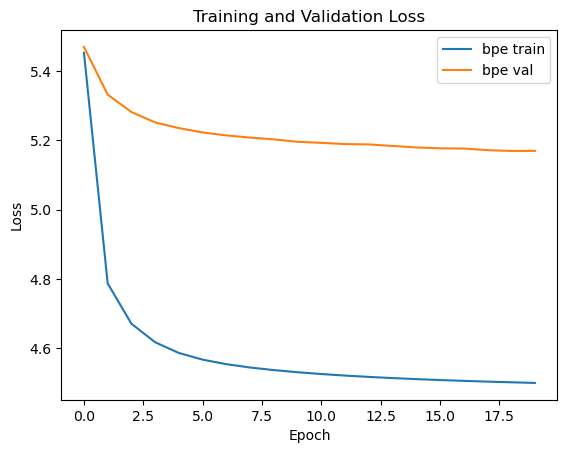

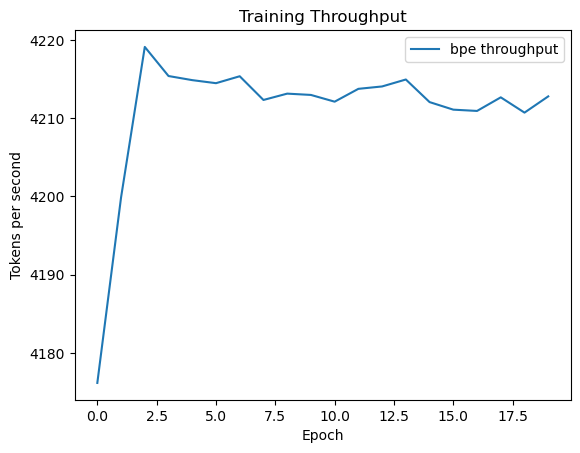

In [6]:
for tokenizer_name in tokenizers:
    history = pickle.load(open(f"history/{tokenizer_name}_training_history.pkl", "rb"))
    plt.plot(history['train_loss'], label=f"{tokenizer_name} train")
    plt.plot(history['val_loss'], label=f"{tokenizer_name} val")    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training and Validation Loss")
    plt.show()

for tokenizer_name in tokenizers:
    plt.plot(history['throughput'], label=f"{tokenizer_name} throughput")
    plt.xlabel("Epoch")
    plt.ylabel("Tokens per second")
    plt.legend()
    plt.title("Training Throughput")
    plt.show()